# Python RAG tutorial with Local LLMs (Ollama)

In [1]:
# Data path
DATA_PATH = "doc.pdf"

In [2]:
from langchain_community.document_loaders import PyPDFLoader

# Load data using pdf loader from langchain library
documents = PyPDFLoader(DATA_PATH).load()

/var/folders/9q/lcw9trwj1fzfr462dyx80xwm0000gn/T/ipykernel_19253/1390365422.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [3]:
documents

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-07-25T00:12:48+00:00', 'author': '', 'keywords': '', 'moddate': '2024-07-25T00:12:48+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'doc.pdf', 'total_pages': 6, 'page': 0, 'page_label': '1'}, page_content='ASSESSING THE ROLE OF CLINICAL SUMMARIZATION AND\nPATIENT CHART REVIEW WITHIN COMMUNICATIONS , M EDICAL\nMANAGEMENT , AND DIAGNOSTICS\nChanseo Lee\nYale School of Medicine and Sporo Health\nNew Haven, CT 06510\nchanseo.lee@yale.edu\nKimon-Aristotelis V ogt\nSporo Health\nBoston, MA 02134\nkvogt@sporohealth.com\nSonu Kumar\nSporo Health\nBoston, MA 02134\nsonu@sporohealth.com\nJuly 25, 2024\nABSTRACT\nEffective summarization of unstructured patient data in electronic health records (EHRs) is crucial\nfor accurate diagnosis and efficient patient care, yet

### Document is too big on its own, we need to split it into chunks

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

In [5]:
# Function to split documents into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=80,
    length_function=len,
    is_separator_regex=False,
)

In [6]:
# Split documents into chunks
chunks = text_splitter.split_documents(documents)

print("Chunks:", len(chunks))
print("\nChunk example:\n\n", chunks[1])

Chunks: 33

Chunk example:

 page_content='and management. It also discusses recent efforts to integrate artificial intelligence (AI) into clinical
summarization tasks, and its transformative impact on the clinician’s potential, including but not
limited to reductions of administrative burden and improved patient-centered care.
1 Introduction
Patient information is critical in the delivery of effective care – thousands of practices, tools, and techniques have been
developed in patient interview, health record storage, and physical examination purely for the sake of effective usage of
key patient information. Clinicians must have an effective understanding of a patient – including but not limited to
the history of present illness (HPI), past medical history (PMH), family history (FH), and more. This allows them to' metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-07-25T00:12:48+00:00', 'author': '', 'keywords': '', 'moddate': '2024-07-25T00

### Create embedding for each chunk

In [7]:
# Create embedding function so we can use it to create the database and then query the database
# Important to use the same embedding function for both creating the database and querying it, otherwise the results will be inconsistent
from langchain_ollama import OllamaLLM as Ollama
from langchain_ollama import OllamaEmbeddings

embedding_function = OllamaEmbeddings(model="nomic-embed-text")

### Ollama is a platform that is used to run open source LLMs locally.

### Use embedding function to create vector database (Chroma)

In [8]:
import chromadb
from langchain_chroma import Chroma
import hashlib
from pathlib import Path

# Set the path for the Chroma database
CHROMA_PATH = "chroma_db"

In [9]:
# Create a Chroma database and add the chunks to it
db = Chroma(
    persist_directory=CHROMA_PATH,
    embedding_function=embedding_function,
)

In [10]:
# Function that splits PDFs into chunks and adds to vector base without duplicates
def add_pdf_to_chroma(pdf_path):
    # Load PDF
    documents = PyPDFLoader(pdf_path).load()

    # Add source metadata
    source_name = Path(pdf_path).name

    for document in documents:
        document.metadata["source_document"] = source_name

    # Split PDF into chunks
    new_chunks = text_splitter.split_documents(documents)

    # Deterministic IDs based on source + chunk index + content hash
    chunk_ids = [
        hashlib.sha256(f"{source_name}-{i}-{chunk.page_content}".encode()).hexdigest()
        for i, chunk in enumerate(new_chunks)
    ]

    # Remove any existing chunks from this source before re-adding
    db.delete(where={"source_document": source_name})

    # Add chunks to Chroma
    db.add_documents(documents=new_chunks, ids=chunk_ids)

    print(f"Successfully added {len(new_chunks)} chunks from {source_name}")

In [11]:
add_pdf_to_chroma(DATA_PATH)

Successfully added 33 chunks from doc.pdf


In [12]:
collection = db.get()

print("Number of documents in vector store:")
print(len(collection["ids"]))

Number of documents in vector store:
96


In [13]:
# Add new PDF to vector base
add_pdf_to_chroma("Electronic_Health_Records_EHR.pdf")

Successfully added 60 chunks from Electronic_Health_Records_EHR.pdf


In [14]:
collection = db.get()

print("Number of documents in vector store:")
print(len(collection["ids"]))

Number of documents in vector store:
96


### Running RAG locally

In [15]:
from langchain_core.prompts import ChatPromptTemplate

In [16]:
PROMPT_TEMPLATE = """
Answer the question based only on the following context:
{context}

---
Answer the question based on the above context: {question}
"""

In [17]:
# To get relevant context we need to search the database
# Gives top k relevant chunks for our question
results = db.similarity_search_with_score("What are EHRs?", k=5)

In [18]:
results

[(Document(id='7375ab67244fe1ebb2bbbb95d5fd285c7a1ab716db0a07de6d070020a309d2da', metadata={'page': 0, 'source': 'Electronic_Health_Records_EHR.pdf', 'producer': 'Microsoft® Office Word 2007', 'page_label': '1', 'author': 'Administrator', 'creationdate': '2012-07-10T11:12:24-06:00', 'title': 'Administrative Structure of the program:  To understand where the program is now, it is important to trace it’s somewhat convoluted developmental trajectory', 'creator': 'Microsoft® Office Word 2007', 'moddate': '2012-07-10T11:12:24-06:00', 'source_document': 'Electronic_Health_Records_EHR.pdf', 'total_pages': 10}, page_content='(HIMSS) adopted this official definition of an EHR: \nT'),
  0.4042031168937683),
 (Document(id='cfa139561e9838e712bac5a01e588fa2191a64d9e64574e5e14ec085b1b2786f', metadata={'title': 'Administrative Structure of the program:  To understand where the program is now, it is important to trace it’s somewhat convoluted developmental trajectory', 'total_pages': 10, 'source_docum

### Visualise embeddings using PCA

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [79]:
# Get the underlying Chroma collection

collection = db._collection

data = collection.get(include=["embeddings", "documents"])

embeddings = np.array(data["embeddings"])
documents = data["documents"]

print("Embedding shape:", embeddings.shape)

Embedding shape: (96, 768)


In [80]:
# Reduce embeddings to 2 dimensions using PCA

pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

print("Original embedding shape:", embeddings.shape)
print("PCA embedding shape:", embeddings_2d.shape)

Original embedding shape: (96, 768)
PCA embedding shape: (96, 2)


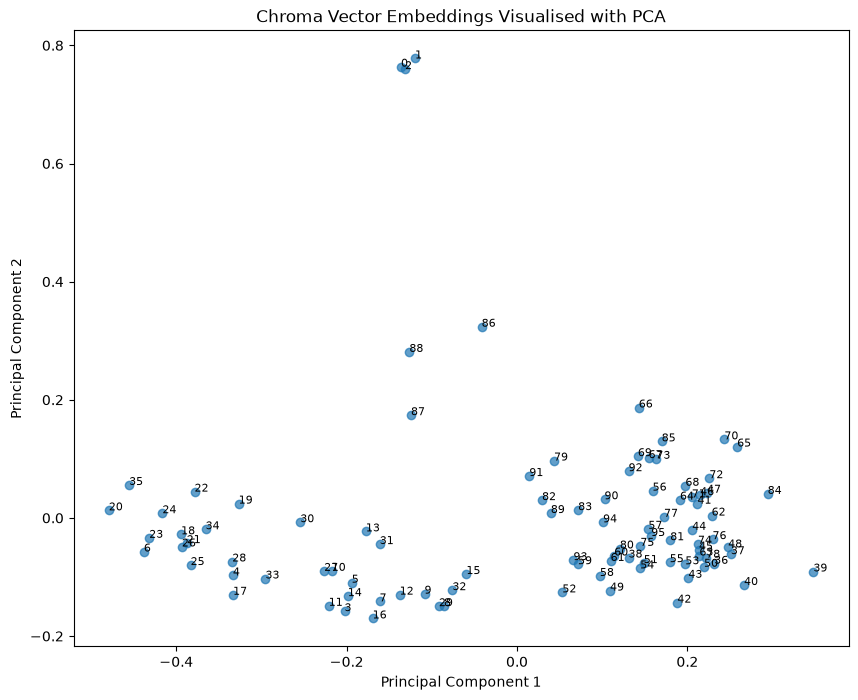

In [81]:
# Visualise embeddings

plt.figure(figsize=(10, 8))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    alpha=0.7
)

plt.title("Chroma Vector Embeddings Visualised with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Label points with chunk numbers
for i in range(len(embeddings_2d)):
    plt.annotate(str(i), (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8)

plt.show()

### Lower score means more similar for Chroma vector bases as it means theres a shorter distance between the chunk and the query text.

In [82]:
def query_rag(query_text: str):
    results = db.similarity_search_with_score(query_text, k=5)
    
    # Prompt
    # Join the content of the retreived chunks into a single string to provide context for the LLM
    context_text = "\n\n---\n\n".join([doc.page_content for doc, _score in results])

    # Load the prompt template and format it with the context and question
    prompt_template = ChatPromptTemplate.from_template(PROMPT_TEMPLATE)
    prompt = prompt_template.format(context=context_text, question=query_text)
    
    # Invoke LLM with the prompt using Ollama model
    model = Ollama(model = "llama3.1:8b")
    response_text = model.invoke(prompt)

    return response_text

In [33]:
query_rag("What are EHRs?")

'According to the definition provided by the HIMSS (Health Information Management Systems Society), an Electronic Health Record (EHR) is:\n\n"A longitudinal electronic record of patient health information generated by one or more encounters in any care delivery setting. Included in this information are patient demographics, progress notes, problems, medications, vital signs, past medical history, immunizations, laboratory data, and radiology reports."\n\nIn simpler terms, an EHR is an electronic version of a patient\'s health record that contains a comprehensive and up-to-date summary of a patient\'s medical history and treatment.'

In [34]:
query_rag("What is a fish?")

'There is no mention of a fish in the provided context.'

## Tavily search integration
### Allows real time web search to AI agents
### Great for retrieving up-to-date web data — ideal for dynamic and current-event-based use cases.

In [19]:
import os
from dotenv import load_dotenv
from tavily import TavilyClient

load_dotenv()

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

In [20]:
result = tavily_client.search(query="What are EHRs?")

In [21]:
result

{'query': 'What are EHRs?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ncbi.nlm.nih.gov/books/NBK597466',
   'title': 'Electronic Health Records as Source of Research Data - NCBI',
   'content': 'An electronic health record (EHR) is a digital version of a patient’s medical history which may include all of the key administrative clinical data relevant to that person’s care, including demographics, vital signs, diagnoses, treatment plans, medications, past medical history, allergies, immunizations, radiology reports, and laboratory and test results. EHRs are real-time, patient-centered records that make information available instantly and securely to authorized users. EHRs have been [...] Electronic health records (EHRs) are the collection of all digitalized information regarding individual’s health. EHRs are not only the base for storing clinical information for archival purposes, but they are also the bedrock on which clinical resear

In [38]:
all_content = "\n\n---\n\n".join(r["content"] for r in result["results"])
print(all_content)

An electronic health record (EHR) is a digital version of a patient’s medical history which may include all of the key administrative clinical data relevant to that person’s care, including demographics, vital signs, diagnoses, treatment plans, medications, past medical history, allergies, immunizations, radiology reports, and laboratory and test results. EHRs are real-time, patient-centered records that make information available instantly and securely to authorized users. EHRs have been [...] Electronic health records (EHRs) are the collection of all digitalized information regarding individual’s health. EHRs are not only the base for storing clinical information for archival purposes, but they are also the bedrock on which clinical research and data science thrive. In this chapter, we describe the main aspects of good quality EHR systems, and some of the standard practices in their implementation, to then conclude with details and reflections on their governance and private [...] EH

In [39]:
print(result["results"][0]["content"])

An electronic health record (EHR) is a digital version of a patient’s medical history which may include all of the key administrative clinical data relevant to that person’s care, including demographics, vital signs, diagnoses, treatment plans, medications, past medical history, allergies, immunizations, radiology reports, and laboratory and test results. EHRs are real-time, patient-centered records that make information available instantly and securely to authorized users. EHRs have been [...] Electronic health records (EHRs) are the collection of all digitalized information regarding individual’s health. EHRs are not only the base for storing clinical information for archival purposes, but they are also the bedrock on which clinical research and data science thrive. In this chapter, we describe the main aspects of good quality EHR systems, and some of the standard practices in their implementation, to then conclude with details and reflections on their governance and private [...] EH

## Crew AI Agent creation
### CrewAI simplifies the process of designing, managing, and scaling multi-agent AI systems. It brings structure and collaboration to autonomous AI workflows, making it perfect for tasks requiring research, synthesis, and review.
### Simulates team-based AI problem solving.

In [40]:
from crewai.tools  import tool
from crewai import Agent, Task, Crew, Process, LLM
from crewai.tasks.conditional_task import ConditionalTask
from crewai.tasks.task_output import TaskOutput
from crewai_tools import PDFSearchTool
from pydantic import BaseModel, Field

### Setup LLM

In [41]:
llm = LLM(
    model="ollama/llama3.1:8b",
    base_url="http://localhost:11434"
)

### Setup tools

In [42]:
# pdf search tool
@tool("pdf_search_tool")
def pdf_search_tool(query_text: str) -> str:
    """Search the PDF/RAG knowledge base for information relevant to the query."""
    results = db.similarity_search_with_score(query_text, k=5)
        
    # Prompt
    # Join the content of the retreived chunks into a single string to provide context for the LLM
    context_text = "\n\n---\n\n".join([doc.page_content for doc, _score in results])

    return context_text

In [43]:
@tool("web_search_tool")
def web_search_tool(query: str) -> str:
    """Search the web for information relevant to the user's query."""

    response = tavily_client.search(query=query, max_results=3)

    return "\n\n".join(
        [
            f"Title: {result['title']}\n"
            f"Content: {result['content']}\n"
            f"URL: {result['url']}"
            for result in response["results"]
        ]
    )

In [44]:
# Structured output for the grading step
# Returns a real boolean field. Downstream code branches on 'sufficient'.

class RetrievalGrade(BaseModel):
    sufficient: bool = Field(description="True if the retrieved_content fully answers the user query, False otherwise.")

    retrieved_content: str = Field(description="The relevant text pulled from the PDF vector store, copied as-is. Empty string if nothing relevant was found.")

    reasoning: str = Field(description="One or two sentences on why the content is or isn't sufficient.")

### Agents

In [52]:
# Agents

retriever_agent = Agent(
    role="PDF Retrieval Specialist",
    goal=("""Retrieve the most relevant passages from the PDF knowledge base for the user query: {query}.
            Return the retrieved text exactly as found, without summarizing or rephrasing it."""),
    backstory=("""You are a meticulous research assistant. You only report what the vector store actually returns, you never invent or paraphrase content, and you clearly say when nothing relevant came back."""),
    tools=[pdf_search_tool],
    llm=llm,
    verbose=True,
)

grader_agent = Agent(
    role="Retrieval Quality Grader",
    goal=("""Judge whether the content retrieved from the PDF is sufficient, on its own, to fully answer the user query: {query}.
            Be strict: if the content is only tangentially related, partial, or missing key details, mark it as insufficient."""),
    backstory=("""You are a skeptical fact-checker. You never assume missing information can be inferred. You output a clear, structured verdict every time."""),
    llm=llm,
    verbose=True,
)

web_search_agent = Agent(
    role="Web Research Specialist",
    goal=("""Search the web for information that fills the gaps left by the PDF retrieval for the query: {query}.
            Focus specifically on what was missing, not on re-covering ground already found in the PDF."""),
    backstory=("""You are a resourceful researcher who finds current, accurate information online and reports it plainly, citing where it came from when possible."""),
    tools=[web_search_tool],
    llm=llm,
    verbose=True,
)

synthesizer_agent = Agent(
    role="Response Synthesizer",
    goal=("""Combine all available retrieved information into one clear, concise answer to the user query: {query}."""),
    backstory=("""You are a skilled communicator who turns raw research notes into a clean, direct answer — no hedging, no filler."""),
    llm=llm,
    verbose=True,
)

hallucination_checker_agent = Agent(
    role="Hallucination Checker",
    goal=("""Check every factual claim in the proposed answer for the query: {query} against the retrieved context.
        Flag any claim that is not directly stated or clearly implied by the context.
        Do not use outside knowledge to judge correctness, only whether the context supports the claim."""),
    backstory=("""You are an extremely literal fact-checker.
        You do not care whether a claim is true in the real world, you only care whether the provided context actually says it.
        If the context doesn't mention it, it's unsupported, even if you personally know it to be true."""),
    llm=llm,
    verbose=True,
)

### Tasks

In [53]:
# Tasks

retrieval_task = Task(
    description=("""Search the PDF vector store for information relevant to the user query: {query}. Return the raw retrieved passages."""),
    expected_output="The relevant passages retrieved from the PDF, verbatim.",
    agent=retriever_agent,
)

grading_task = Task(
    description=("""Review the content retrieved by the previous task for the query: {query}. Decide whether it is sufficient to fully answer the query."""),
    expected_output="A structured grade with 'sufficient', 'retrieved_content', and 'reasoning' fields.",
    agent=grader_agent,
    context=[retrieval_task],
    output_pydantic=RetrievalGrade,
)

# Checks whether information is sufficient or not, if false then function returns True, meaning to do the websearch
def needs_web_search(output: TaskOutput) -> bool:
    return output.pydantic.sufficient is False

web_search_task = ConditionalTask(
    description=("""The PDF content was graded insufficient for the query: {query}. Search the web to find the missing information."""),
    expected_output="Additional information from the web that fills the gap.",
    agent=web_search_agent,
    context=[grading_task],
    condition=needs_web_search,
)

synthesis_task = Task(
        description=("""Using the PDF retrieval, grading, and any available web research, write the best concise answer to: {query}.
            If nothing relevant was found, say so explicitly."""),
        expected_output="A concise final answer grounded in the supplied context.",
        agent=synthesizer_agent,
        context=[grading_task, web_search_task],
    )

hallucination_task = Task(
        description=("""Check the proposed answer for {query}.
            For every factual claim, determine whether it is supported by the supplied PDF/web context.
            List unsupported claims and explain what should be removed or corrected."""),
        expected_output=("""A grounded/ungrounded verdict with unsupported claims and reasoning."""),
        agent=hallucination_checker_agent,
        context=[grading_task, web_search_task, synthesis_task],
    )

final_task = Task(
        description=("""Produce the final answer to {query}. Use the draft and hallucination check.
            Remove or correct unsupported claims. Answer directly and concisely. Do not mention internal agents or workflow."""),
        expected_output="The final grounded answer to the user.",
        agent=synthesizer_agent,
        context=[synthesis_task, hallucination_task],
    )

### Assemble CrewAI

In [54]:
# Assemble and run the crew

crew = Crew(
    agents=[retriever_agent, grader_agent, web_search_agent, synthesizer_agent, hallucination_checker_agent],
    tasks=[retrieval_task, grading_task, web_search_task, synthesis_task, hallucination_task, final_task],
    process=Process.sequential,
    verbose=True,
)

In [56]:
result = await crew.kickoff_async(inputs={"query": "What are EHRs?"})

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 57a07e99-efc7-44a2-b337-f59a791b9f81                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Search the PDF vector store for information relevant to the user query: What are EHRs?. Return the raw   │
│  retrieved passages.                                                                                            │
│  ID: 2494ad0a-39a3-4c9c-843c-e46474790683                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: PDF Retrieval Specialist                                                                                │
│                                                                                                                 │
│  Task: Search the PDF vector store for information relevant to the user query: What are EHRs?. Return the raw   │
│  retrieved passages.                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#4) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: pdf_search_tool                                                                                          │
│  Args: {'query_text': 'What are EHRs?'}                                                                         │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool pdf_search_tool executed with result: (HIMSS) adopted this official definition of an EHR: 
T

---

American Journal of Health Sciences – Third Quarter 2012 Volume 3, Number 3 
202 http://www.cluteinstitute.com/  © 2012 The Clute Institute...


...

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Response Synthesizer                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  The Electronic Health Record (EHR) is an electronic version of a patient's medical history, maintained by the  │
│  provider over time, and includes all key administrative clinical data relevant to that person's care under a   │
│  particular provider. EHRs are digital versions of patient health information used and maintained by            │
│  healthcare providers across clinical settings, designed to securely document, store, access, and share         │
│  patient information to support care coordination and operational efficiency.                                   │
│                                                                                                                 │
│  EHRs may include information such as:                                                                          │
│                                                                                                                 │
│  * Patient demographics and contact information                                                                 │
│  * Vital signs and medical history                                                                              │
│  * Allergies and immunizations                                                                                  │
│  * Current and past medications                                                                                 │
│  * Laboratory and radiology records                                                                             │
│  * Clinical notes and treatment plans                                                                           │
│                                                                                                                 │
│  EHR systems support more than just digital record storage, but are integrated into many aspects of healthcare  │
│  delivery and organizational operations. They are designed to be interoperable, enabling secure data exchange   │
│  between different healthcare settings.                                                                         │
│                                                                                                                 │
│  EHRs are real-time digital documents that store and organize patient information securely, including medical   │
│  histories, diagnoses, medications, laboratory results, and more.                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Produce the final answer to What are EHRs?. Use the draft and hallucination check.                       │
│              Remove or correct unsupported claims. Answer directly and concisely. Do not mention internal       │
│  agents or workflow.                                                                                            │
│  Agent: Response Synthesizer                                                                                    │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 57a07e99-efc7-44a2-b337-f59a791b9f81                                                                       │
│  Final Output: The Electronic Health Record (EHR) is an electronic version of a patient's medical history,      │
│  maintained by the provider over time, and includes all key administrative clinical data relevant to that       │
│  person's care under a particular provider. EHRs are digital versions of patient health information used and    │
│  maintained by healthcare providers across clinical settings, designed to securely document, store, access,     │
│  and share patient information to support care coordination and operational efficiency.                         │
│                                                                                                                 │
│  EHRs may include information such as:                                                                          │
│                                                                                                                 │
│  * Patient demographics and contact information                                                                 │
│  * Vital signs and medical history                                                                              │
│  * Allergies and immunizations                                                                                  │
│  * Current and past medications                                                                                 │
│  * Laboratory and radiology records                                                                             │
│  * Clinical notes and treatment plans                                                                           │
│                                                                                                                 │
│  EHR systems support more than just digital record storage, but are integrated into many aspects of healthcare  │
│  delivery and organizational operations. They are designed to be interoperable, enabling secure data exchange   │
│  between different healthcare settings.                                                                         │
│                                                                                                                 │
│  EHRs are real-time digital documents that store and organize patient information securely, including medical   │
│  histories, diagnoses, medications, laboratory results, and more.                                               │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [57]:
print(result)

The Electronic Health Record (EHR) is an electronic version of a patient's medical history, maintained by the provider over time, and includes all key administrative clinical data relevant to that person's care under a particular provider. EHRs are digital versions of patient health information used and maintained by healthcare providers across clinical settings, designed to securely document, store, access, and share patient information to support care coordination and operational efficiency.

EHRs may include information such as:

* Patient demographics and contact information
* Vital signs and medical history
* Allergies and immunizations
* Current and past medications
* Laboratory and radiology records
* Clinical notes and treatment plans

EHR systems support more than just digital record storage, but are integrated into many aspects of healthcare delivery and organizational operations. They are designed to be interoperable, enabling secure data exchange between different healthcar

In [58]:
result = await crew.kickoff_async(inputs={"query": "What is a fish?"})

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 57a07e99-efc7-44a2-b337-f59a791b9f81                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Search the PDF vector store for information relevant to the user query: What is a fish?. Return the raw  │
│  retrieved passages.                                                                                            │
│  ID: 2494ad0a-39a3-4c9c-843c-e46474790683                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: PDF Retrieval Specialist                                                                                │
│                                                                                                                 │
│  Task: Search the PDF vector store for information relevant to the user query: What is a fish?. Return the raw  │
│  retrieved passages.                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#5) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: pdf_search_tool                                                                                          │
│  Args: {'query_text': 'What is a fish?'}                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool pdf_search_tool executed with result: (HIMSS) adopted this official definition of an EHR: 
T

---

American Journal of Health Sciences – Third Quarter 2012 Volume 3, Number 3 
202 http://www.cluteinstitute.com/  © 2012 The Clute Institute...

...

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Response Synthesizer                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  A fish is an aquatic, anamniotic, gill-bearing vertebrate animal with a tough cranium to protect the brain,    │
│  but lacking limbs with digits. Fish can be grouped into the more basal jawless fish and the more common jawed  │
│  fish, the latter including all living cartilaginous and bony fish, as well as the extinct placoderms and       │
│  acanthodians. In English, the plural of "fish" is "fish" when referring to individuals and "fishes" when       │
│  referring to species.                                                                                          │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Produce the final answer to What is a fish?. Use the draft and hallucination check.                      │
│              Remove or correct unsupported claims. Answer directly and concisely. Do not mention internal       │
│  agents or workflow.                                                                                            │
│  Agent: Response Synthesizer                                                                                    │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 57a07e99-efc7-44a2-b337-f59a791b9f81                                                                       │
│  Final Output: A fish is an aquatic, anamniotic, gill-bearing vertebrate animal with a tough cranium to         │
│  protect the brain, but lacking limbs with digits. Fish can be grouped into the more basal jawless fish and     │
│  the more common jawed fish, the latter including all living cartilaginous and bony fish, as well as the        │
│  extinct placoderms and acanthodians. In English, the plural of "fish" is "fish" when referring to individuals  │
│  and "fishes" when referring to species.                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [51]:
print(result)

The retrieved content from the web fills in the gaps, but it still does not provide a clear definition of what a fish is. Upon reviewing the content, I found that it covers various aspects of fish, including their classification, physiology, and reproductive strategies, but it does not provide a concise definition.

However, based on the content that was retrieved, I can synthesize the information into a comprehensive definition. Here is the complete response:


Fish are a paraphyletic group, meaning they include some descendants from a common ancestor but not all. They are characterized by having streamlined bodies, gills, fins, and being cold-blooded vertebrates, although some species have abandoned streamlining in favour of other body shapes and some are able to breathe air on land. They have a wide range of body shapes and ways of life, with some laying eggs, being oviparous, ovoviviparous, or viviparous.
